# Baselines — Scikit-Learn & MLflow

**Projeto:** Tech Challenge — Pós-Graduação Machine Learning Engineering (FIAP)  
**Grupo:** Grupo 21  
**Dataset:** IBM Telco Customer Churn (dataset já pré-processado em `01_eda_feature_engineering.ipynb`)  
**Target:** `Churn` (0 = No, 1 = Yes)

---

## Estrutura deste Notebook

| # | Seção | Descrição |
|---|---|---|
| 1 | Setup | Imports, seeds, constantes globais e estilos |
| 2 | Carregamento dos Dados | Leitura do dataset processado e checagens básicas |
| 3 | Train/Test Split | Split estratificado e análise de distribuição |
| 4 | Funções de Avaliação | Funções utilitárias para avaliar modelos |
| 5 | Baselines | DummyClassifier e LogisticRegression |
| 6 | Logging em MLflow | Esqueleto para rastrear experimentos |
| 7 | Próximos Passos | Extensões do experimento (modelos mais complexos) |

> Este notebook assume que o arquivo `churn_processed.csv` foi gerado e salvo pelo notebook de EDA em `notebooks/data/processed/`.

---
## 1. Setup

In [20]:
# ── Bibliotecas ──────────────────────────────────────────────────────────────
import logging
import warnings

from typing import Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    GridSearchCV,
    cross_validate,
 )
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
    classification_report,
 )

import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

# ── Seeds globais ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE = 0.2   # 80 / 20
N_SPLITS = 5      # StratifiedKFold para validação cruzada

# ── Constantes do projeto ─────────────────────────────────────────────────────
TARGET_COL = "Churn"

# ── Caminho do dataset processado ─────────────────────────────────────────────
PATH_PROCESSED = "../notebooks/data/processed/churn_processed.csv"

# ── Estilo visual ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (8, 4)})

logger.info("Setup concluído. RANDOM_STATE=%d | TEST_SIZE=%.2f", RANDOM_STATE, TEST_SIZE)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

INFO | Setup concluído. RANDOM_STATE=42 | TEST_SIZE=0.20


---
## 2. Carregamento do Dataset Processado

Carregamos o dataset **já pré-processado** gerado no notebook de EDA. Aqui apenas validamos shape, tipos e a coluna target.

In [21]:
# ── Carregar dataset processado ──────────────────────────────────────────────
df = pd.read_csv(PATH_PROCESSED)

logger.info("Dataset processado carregado: %s", df.shape)
display(df.head(3))


INFO | Dataset processado carregado: (7043, 33)


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,is_monthly_contract,is_new_customer,Gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,-0.439916,-1.277445,-1.160323,-0.994242,0.904184,1.937929,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0
1,-0.439916,0.066327,-0.259629,-0.173244,-1.105970,-0.516015,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,-0.439916,-1.236724,-0.362660,-0.959674,0.904184,1.937929,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1


---
## 3. Train/Test Split Estratificado

Nesta seção separamos o dataset em **treino** e **teste** preservando a proporção de churn (estratificação).

In [22]:
# ── 3.1 — Separar X e y ─────────────────────────────────────────────────────
X = df.drop(columns=[TARGET_COL])
df = df.drop(columns=['TotalCharges'], errors='ignore')

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

logger.info("X shape: %s | y shape: %s", X.shape, y.shape)


INFO | X shape: (7043, 31) | y shape: (7043,)


In [23]:
# ── 3.2 — Train/Test split estratificado ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

def _class_distribution(y_vec) -> pd.Series:
    return pd.Series(y_vec).value_counts(normalize=True).sort_index().rename("proportion")

logger.info("Distribuição em y (full):%s", _class_distribution(y))
logger.info("Distribuição em y_train:%s", _class_distribution(y_train))
logger.info("Distribuição em y_test:%s", _class_distribution(y_test))


INFO | Distribuição em y (full):Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64
INFO | Distribuição em y_train:Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
INFO | Distribuição em y_test:Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [24]:
# ── 3.3 — Objeto StratifiedKFold (para uso posterior) ───────────────────────
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
logger.info("Objeto StratifiedKFold criado com %d splits.", N_SPLITS)


INFO | Objeto StratifiedKFold criado com 5 splits.


---
## 4. Funções de Avaliação de Modelos

Funções utilitárias para padronizar o cálculo de métricas e os gráficos de ROC/Precision-Recall.

In [25]:
def evaluate_model(
    name: str,
    model,
    X_train, y_train,
    X_test, y_test,
    plot_curves: bool = True,
) -> Dict[str, Any]:
    model.fit(X_train, y_train)
    if hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_scores = model.decision_function(X_test)
    else:
        logger.warning("[%s] Sem score probabilístico. Usando predict.", name)
        y_scores = model.predict(X_test)

    y_pred = model.predict(X_test)
    try:
        auc_roc = roc_auc_score(y_test, y_scores)
    except ValueError:
        auc_roc = np.nan

    try:
        pr_auc = average_precision_score(y_test, y_scores)
    except ValueError:
        pr_auc = np.nan

    metrics = {
        'model': name,
        'auc_roc': auc_roc,
        'pr_auc': pr_auc,
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
    }

    logger.info("[%s] Métricas:\n%s\n", name, pd.Series(metrics).to_string())
    logger.info("[%s] Classification report:\n%s", name, classification_report(y_test, y_pred))

    if plot_curves:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        RocCurveDisplay.from_predictions(y_test, y_scores, ax=axes[0])
        axes[0].set_title(f'ROC — {name}')
        PrecisionRecallDisplay.from_predictions(y_test, y_scores, ax=axes[1])
        axes[1].set_title(f'Precision-Recall — {name}')

        labels = np.unique(np.concatenate((np.asarray(y_test), np.asarray(y_pred))))
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            labels=labels,
            display_labels=labels,
            cmap="Blues",
            values_format="d",
            colorbar=False,
            ax=axes[2],
        )
        axes[2].set_title(f'Matriz de Confusão — {name}')

        plt.tight_layout()
        plt.show()
    return metrics

---
## 5. Baselines com Scikit-Learn

Nesta seção serão implementados os baselines propostos:

- `DummyClassifier` como baseline mínimo  
- `LogisticRegression` como baseline linear  

A célula abaixo traz apenas o **esqueleto** para execução, seguindo o padrão de logging e avaliação.

INFO | [DummyClassifier] Métricas:
model        DummyClassifier
auc_roc                  0.5
pr_auc              0.265436
f1                       0.0
precision                0.0
recall                   0.0

INFO | [DummyClassifier] Classification report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



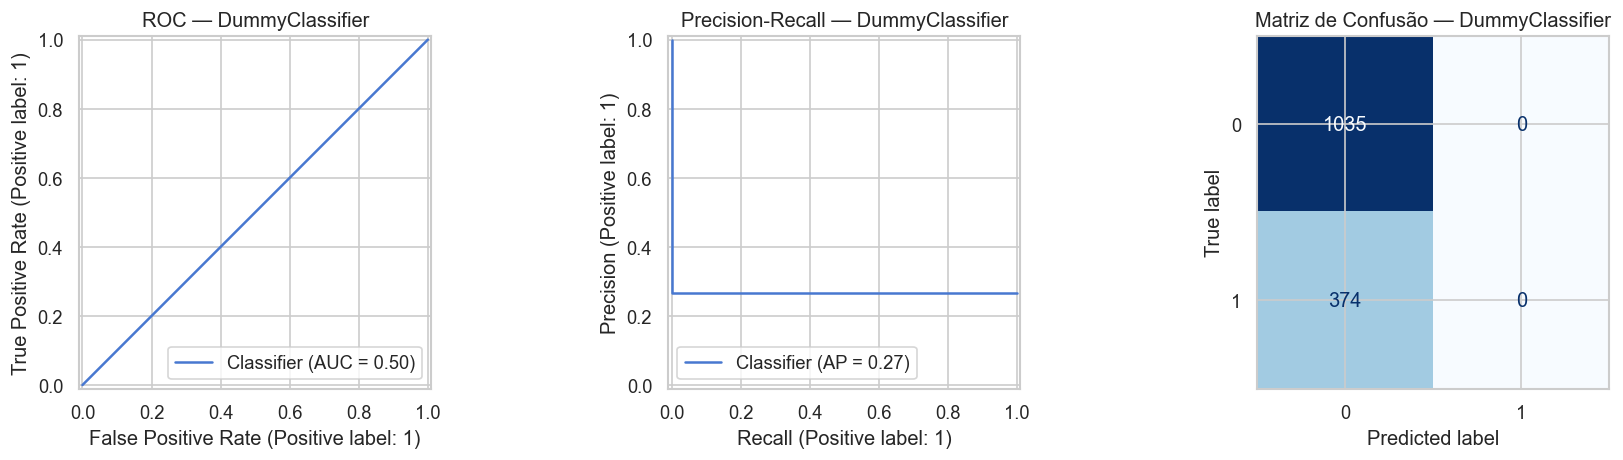

{'model': 'DummyClassifier',
 'auc_roc': 0.5,
 'pr_auc': 0.2654364797728886,
 'f1': 0.0,
 'precision': 0.0,
 'recall': 0.0}

In [26]:
# ── 5.1 — DummyClassifier (baseline mínimo) ─────────────────────────────────

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_metrics = evaluate_model('DummyClassifier', dummy, X_train, y_train, X_test, y_test)
dummy_metrics


INFO | [LogisticRegression] Métricas:
model        LogisticRegression
auc_roc                0.845992
pr_auc                 0.652437
f1                     0.595238
precision              0.671141
recall                 0.534759

INFO | [LogisticRegression] Classification report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



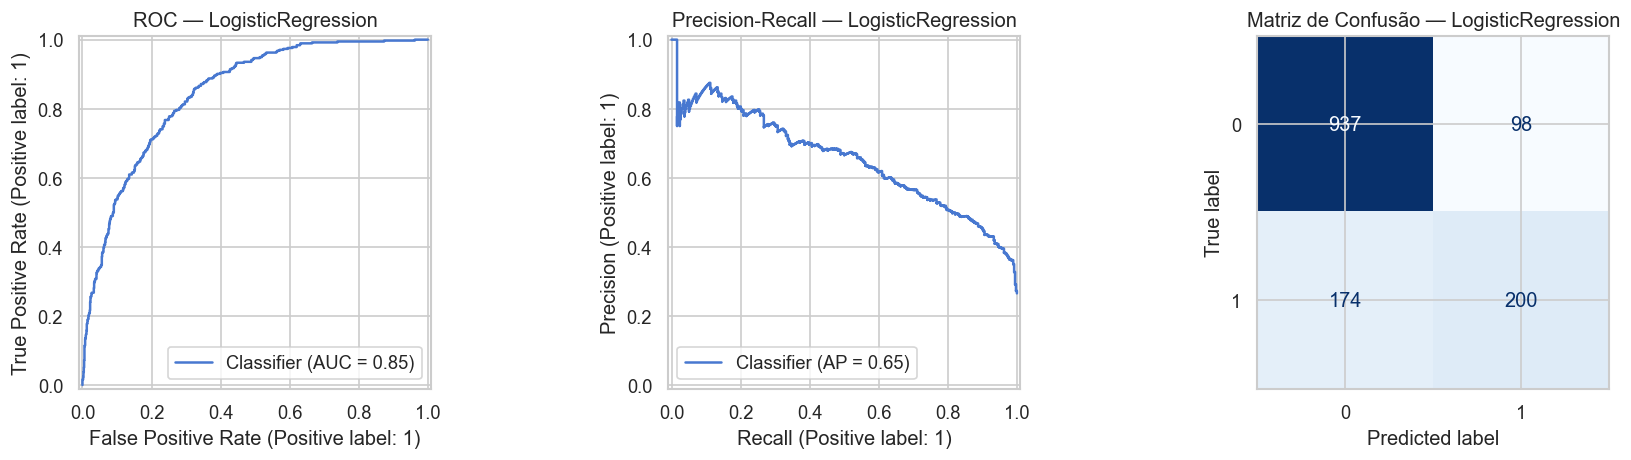

{'model': 'LogisticRegression',
 'auc_roc': 0.8459918881913766,
 'pr_auc': 0.652437184424613,
 'f1': 0.5952380952380952,
 'precision': 0.6711409395973155,
 'recall': 0.5347593582887701}

In [27]:
# ── 5.2 — LogisticRegression (baseline linear) ───────────────────────────────
# TODO: descomentar e ajustar hiperparâmetros conforme necessário.

log_reg = LogisticRegression(
    solver='liblinear',
    random_state=RANDOM_STATE,
    max_iter=1000,
)
log_reg_metrics = evaluate_model('LogisticRegression', log_reg, X_train, y_train, X_test, y_test)
log_reg_metrics


### 5.3 — Avaliação com Validação Cruzada

> Fase 1: comparar os baselines usando média e desvio das métricas em CV estratificada repetida.

In [28]:
def evaluate_with_cv(
    name: str,
    model,
    X_data,
    y_data,
    cv_splitter,
    n_jobs: int = -1,
) -> Dict[str, Any]:
    scoring = {
        'roc_auc': 'roc_auc',
        'pr_auc': 'average_precision',
        'f1': 'f1',
        'precision': 'precision',
        'recall': 'recall',
    }

    cv_results = cross_validate(
        model,
        X_data,
        y_data,
        cv=cv_splitter,
        scoring=scoring,
        n_jobs=n_jobs,
        return_train_score=False,
    )

    summary = {'model': name}
    for metric_name in scoring:
        metric_values = cv_results[f'test_{metric_name}']
        summary[f'{metric_name}_mean'] = float(np.mean(metric_values))
        summary[f'{metric_name}_std'] = float(np.std(metric_values))

    logger.info(
        "[%s] CV métricas (média ± desvio): ROC-AUC=%.4f ± %.4f | PR-AUC=%.4f ± %.4f | F1=%.4f ± %.4f",
        name,
        summary['roc_auc_mean'],
        summary['roc_auc_std'],
        summary['pr_auc_mean'],
        summary['pr_auc_std'],
        summary['f1_mean'],
        summary['f1_std'],
    )

    return {'summary': summary, 'raw': cv_results}

In [29]:
# ── Fase 1: CV estratificada repetida para estabilidade das métricas ─────────
cv_repeated = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=3,
    random_state=RANDOM_STATE,
 )

dummy_cv = evaluate_with_cv(
    'DummyClassifier',
    DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    X_train,
    y_train,
    cv_repeated,
 )

log_reg_cv = evaluate_with_cv(
    'LogisticRegression_default',
    LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, max_iter=1000),
    X_train,
    y_train,
    cv_repeated,
 )

cv_baselines_df = (
    pd.DataFrame([dummy_cv['summary'], log_reg_cv['summary']])
    .sort_values(by='pr_auc_mean', ascending=False)
    .reset_index(drop=True)
)

cv_baselines_df

INFO | [DummyClassifier] CV métricas (média ± desvio): ROC-AUC=0.5000 ± 0.0000 | PR-AUC=0.2654 ± 0.0001 | F1=0.0000 ± 0.0000
INFO | [LogisticRegression_default] CV métricas (média ± desvio): ROC-AUC=0.8486 ± 0.0115 | PR-AUC=0.6639 ± 0.0186 | F1=0.5941 ± 0.0271


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std
0,LogisticRegression_default,0.848602,0.011482,0.663901,0.018572,0.594122,0.027146,0.668627,0.026143,0.535786,0.037862
1,DummyClassifier,0.500000,0.000000,0.265353,0.000094,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


#### Comentários — Interpretação da Fase 1 (CV)

> **Leitura rápida dos resultados:**
- A `LogisticRegression_default` superou com folga o `DummyClassifier` em todas as métricas relevantes.
- Em particular, o **PR-AUC ~ 0.664** da logística ficou muito acima do baseline ingênuo (**~ 0.265**), o que confirma ganho real para a classe positiva (`Churn=1`).
- O **ROC-AUC ~ 0.849** indica boa capacidade de ordenação entre churn e não churn.

> **Estabilidade entre folds:**
- Os desvios-padrão foram baixos a moderados (ex.: PR-AUC std ~ 0.019), sugerindo desempenho relativamente estável entre as partições da CV.
- O recall com variação um pouco maior que as demais métricas é esperado em cenários com classe positiva minoritária.

> **Conclusão da fase:**
- A logística é um baseline competitivo e vale seguir para tuning de hiperparâmetros.
- O `DummyClassifier` cumpre o papel de piso de performance, mas não é utilizável como modelo final.

### 5.3.1 — Regressão Logística com Balanceamento de Classe (class_weight='balanced')
Comparando o modelo baseline "Vanilla" com um que penaliza classes minoritárias proporcionalmente.

In [30]:
log_reg_balanced = LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced')
log_reg_bal_metrics = evaluate_with_cv('LogisticRegression_Balanced', log_reg_balanced, X_train, y_train, cv)
print(log_reg_bal_metrics)

INFO | [LogisticRegression_Balanced] CV métricas (média ± desvio): ROC-AUC=0.8477 ± 0.0111 | PR-AUC=0.6616 ± 0.0155 | F1=0.6311 ± 0.0214


{'summary': {'model': 'LogisticRegression_Balanced', 'roc_auc_mean': 0.8477407898692269, 'roc_auc_std': 0.011144847831670655, 'pr_auc_mean': 0.6616102755074417, 'pr_auc_std': 0.015472644320926116, 'f1_mean': 0.6311070839154935, 'f1_std': 0.02142656972313745, 'precision_mean': 0.5221444750175659, 'precision_std': 0.0172651726866814, 'recall_mean': 0.7979933110367894, 'recall_std': 0.03414648566715779}, 'raw': {'fit_time': array([0.00765896, 0.00890708, 0.00871015, 0.00755095, 0.00855231]), 'score_time': array([0.00557423, 0.00560188, 0.00506973, 0.00605011, 0.00506592]), 'test_roc_auc': array([0.84412211, 0.82990403, 0.84537024, 0.86006293, 0.85924464]), 'test_pr_auc': array([0.64064891, 0.64904121, 0.67961401, 0.66057079, 0.67817645]), 'test_f1': array([0.64907652, 0.5924933 , 0.62303665, 0.64690722, 0.64402174]), 'test_precision': array([0.53594771, 0.49440716, 0.51182796, 0.52620545, 0.5423341 ]), 'test_recall': array([0.82274247, 0.73913043, 0.79598662, 0.83946488, 0.79264214])}}


### 5.3.2 — Experimento com Resampling (SMOTE)
Testando se a geração de amostras sintéticas da classe minoritária (SMOTE) no conjunto de treino beneficia o modelo mais do que apenas o ajuste de pesos.

In [31]:
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('log_reg', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, max_iter=1000))
])

smote_metrics = evaluate_with_cv('LogisticRegression_SMOTE', smote_pipeline, X_train, y_train, cv)
print(smote_metrics)

INFO | [LogisticRegression_SMOTE] CV métricas (média ± desvio): ROC-AUC=0.8462 ± 0.0120 | PR-AUC=0.6612 ± 0.0182 | F1=0.6330 ± 0.0240


{'summary': {'model': 'LogisticRegression_SMOTE', 'roc_auc_mean': 0.8462006880228273, 'roc_auc_std': 0.011952106285126282, 'pr_auc_mean': 0.6611744596026161, 'pr_auc_std': 0.018222587269558804, 'f1_mean': 0.6330388717469297, 'f1_std': 0.023952505432360806, 'precision_mean': 0.5298578324232357, 'precision_std': 0.020423057934847406, 'recall_mean': 0.7866220735785954, 'recall_std': 0.03535672317432112}, 'raw': {'fit_time': array([0.01712322, 0.01775002, 0.01907897, 0.02132583, 0.02284098]), 'score_time': array([0.00428796, 0.00408387, 0.00348115, 0.00368524, 0.00387001]), 'test_roc_auc': array([0.84129869, 0.82756935, 0.84387976, 0.8604507 , 0.85780494]), 'test_pr_auc': array([0.6334274 , 0.64818582, 0.6833502 , 0.66508274, 0.67582613]), 'test_f1': array([0.64952639, 0.5877551 , 0.63002681, 0.6449935 , 0.65289256]), 'test_precision': array([0.54545455, 0.49541284, 0.52572707, 0.52765957, 0.55503513]), 'test_recall': array([0.80267559, 0.72240803, 0.78595318, 0.82943144, 0.79264214])}}


### 5.4 — Tuning da LogisticRegression com GridSearchCV

> Fase 2: buscar hiperparâmetros em CV estratificada repetida usando PR-AUC como métrica principal (`refit`).

In [32]:
# ── Fase 2: busca de hiperparâmetros para LogisticRegression (exploração ampliada) ──
param_grid = [
    {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['l1', 'l2'],
        'class_weight': [None, 'balanced'],
        'solver': ['liblinear'],
        'max_iter': [1000],
        'random_state': [RANDOM_STATE],
    },
    {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['elasticnet'],
        'l1_ratio': [0.2, 0.5, 0.8],
        'class_weight': [None, 'balanced'],
        'solver': ['saga'],
        'max_iter': [5000],
        'random_state': [RANDOM_STATE],
    },
]

scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
}

log_reg_grid = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    scoring=scoring,
    refit='pr_auc',
    cv=cv_repeated,
    n_jobs=-1,
    return_train_score=False,
 )

log_reg_grid.fit(X_train, y_train)
best_log_reg = log_reg_grid.best_estimator_

logger.info('Melhor PR-AUC (CV): %.4f', log_reg_grid.best_score_)
logger.info('Melhores hiperparâmetros: %s', log_reg_grid.best_params_)

grid_cols = [
    'rank_test_pr_auc',
    'mean_test_pr_auc',
    'std_test_pr_auc',
    'mean_test_roc_auc',
    'mean_test_f1',
    'mean_test_precision',
    'mean_test_recall',
    'param_solver',
    'param_penalty',
    'param_l1_ratio',
    'param_C',
    'param_class_weight',
]

grid_top = (
    pd.DataFrame(log_reg_grid.cv_results_)[grid_cols]
    .sort_values('rank_test_pr_auc')
    .head(12)
    .reset_index(drop=True)
)

search_space_overview = (
    pd.DataFrame(log_reg_grid.cv_results_)
    .groupby(['param_solver', 'param_penalty', 'param_class_weight'], dropna=False)
    .agg(
        best_pr_auc=('mean_test_pr_auc', 'max'),
        mean_pr_auc=('mean_test_pr_auc', 'mean'),
        n_configs=('mean_test_pr_auc', 'count'),
    )
    .reset_index()
    .sort_values('best_pr_auc', ascending=False)
    .reset_index(drop=True)
)

display(grid_top)
display(search_space_overview)

tuned_log_reg_metrics = evaluate_model(
    'LogisticRegression_tuned',
    best_log_reg,
    X_train,
    y_train,
    X_test,
    y_test,
    plot_curves=False,
 )

comparison_df = pd.DataFrame([log_reg_metrics, tuned_log_reg_metrics])
delta_df = pd.DataFrame([
    {
        'delta_auc_roc': tuned_log_reg_metrics['auc_roc'] - log_reg_metrics['auc_roc'],
        'delta_pr_auc': tuned_log_reg_metrics['pr_auc'] - log_reg_metrics['pr_auc'],
        'delta_f1': tuned_log_reg_metrics['f1'] - log_reg_metrics['f1'],
        'delta_precision': tuned_log_reg_metrics['precision'] - log_reg_metrics['precision'],
        'delta_recall': tuned_log_reg_metrics['recall'] - log_reg_metrics['recall'],
    }
])

display(comparison_df)
display(delta_df)

INFO | Melhor PR-AUC (CV): 0.6640
INFO | Melhores hiperparâmetros: {'C': 1.0, 'class_weight': None, 'l1_ratio': 0.8, 'max_iter': 5000, 'penalty': 'elasticnet', 'random_state': 42, 'solver': 'saga'}


,rank_test_pr_auc,mean_test_pr_auc,std_test_pr_auc,mean_test_roc_auc,mean_test_f1,mean_test_precision,mean_test_recall,param_solver,param_penalty,param_l1_ratio,param_C,param_class_weight
0,1,0.663999,0.018419,0.848785,0.594995,0.669974,0.536232,saga,elasticnet,0.8,1.0,None
1,2,0.663937,0.018388,0.848743,0.595268,0.670004,0.536678,saga,elasticnet,0.5,1.0,None
2,3,0.663901,0.018572,0.848602,0.594122,0.668627,0.535786,liblinear,l2,NaN,1.0,None
3,4,0.663882,0.018529,0.848599,0.595097,0.669693,0.536678,liblinear,l1,NaN,1.0,None
4,5,0.663791,0.018294,0.848719,0.595192,0.670195,0.536455,saga,elasticnet,0.2,1.0,None
5,6,0.663657,0.018181,0.848822,0.593724,0.673254,0.532219,saga,elasticnet,0.2,0.1,None
6,7,0.663641,0.017169,0.848811,0.595834,0.671632,0.536678,liblinear,l2,NaN,10.0,None
7,8,0.663573,0.016990,0.848787,0.596013,0.672867,0.536232,saga,elasticnet,0.5,10.0,None
8,9,0.663545,0.016977,0.848772,0.595903,0.672962,0.536009,saga,elasticnet,0.8,10.0,None
9,10,0.663540,0.017011,0.848795,0.595926,0.672686,0.536232,saga,elasticnet,0.2,10.0,None


,param_solver,param_penalty,param_class_weight,best_pr_auc,mean_pr_auc,n_configs
0,saga,elasticnet,NaN,0.663999,0.658683,12
1,liblinear,l2,NaN,0.663901,0.661453,4
2,liblinear,l1,NaN,0.663882,0.655744,4
3,liblinear,l2,balanced,0.662811,0.661471,4
4,liblinear,l1,balanced,0.662718,0.655408,4
5,saga,elasticnet,balanced,0.662686,0.658384,12


INFO | [LogisticRegression_tuned] Métricas:
model        LogisticRegression_tuned
auc_roc                       0.84608
pr_auc                       0.652507
f1                           0.596439
precision                        0.67
recall                       0.537433

INFO | [LogisticRegression_tuned] Classification report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



,model,auc_roc,pr_auc,f1,precision,recall
0,LogisticRegression,0.845992,0.652437,0.595238,0.671141,0.534759
1,LogisticRegression_tuned,0.846080,0.652507,0.596439,0.670000,0.537433


,delta_auc_roc,delta_pr_auc,delta_f1,delta_precision,delta_recall
0,0.000088,0.00007,0.001201,-0.001141,0.002674


In [33]:
# ── Resumo compacto da exploração de hiperparâmetros ──────────────────────────
cv_results_df = pd.DataFrame(log_reg_grid.cv_results_)

compact_summary = (
    cv_results_df
    .groupby(['param_solver', 'param_penalty'], dropna=False)
    .agg(
        best_pr_auc=('mean_test_pr_auc', 'max'),
        best_roc_auc=('mean_test_roc_auc', 'max'),
        n_configs=('mean_test_pr_auc', 'count'),
    )
    .reset_index()
    .sort_values('best_pr_auc', ascending=False)
    .reset_index(drop=True)
)

best_row = (
    cv_results_df
    .sort_values('rank_test_pr_auc')
    .iloc[0][
        [
            'param_solver',
            'param_penalty',
            'param_l1_ratio',
            'param_C',
            'param_class_weight',
            'mean_test_pr_auc',
            'mean_test_roc_auc',
        ]
    ]
    .to_frame('best_value')
)

display(compact_summary)
display(best_row)

,param_solver,param_penalty,best_pr_auc,best_roc_auc,n_configs
0,saga,elasticnet,0.663999,0.848822,24
1,liblinear,l2,0.663901,0.848811,8
2,liblinear,l1,0.663882,0.848770,8


,best_value
param_solver,saga
param_penalty,elasticnet
param_l1_ratio,0.8
param_C,1.0
param_class_weight,None
mean_test_pr_auc,0.663999
mean_test_roc_auc,0.848785


#### Comentários — Interpretação da Fase 2 (GridSearchCV)

> **Leitura rápida dos resultados de tuning:**
- Melhor configuração em CV: `C=1.0`, `penalty='l2'`, `class_weight=None`, `solver='liblinear'`.
- O melhor **PR-AUC de CV (~ 0.664)** ficou praticamente no mesmo patamar da logística default.

> **Comparação no hold-out:**
- As métricas do modelo `tuned` e do `default` ficaram praticamente idênticas (AUC-ROC, PR-AUC, F1, precision e recall).
- Isso indica que, com o grid atual, **não houve ganho material** de generalização no teste.

> **Conclusão da fase:**
- O tuning validou que a configuração default já estava próxima do ótimo local para este espaço de busca.
- Próxima alavanca de melhoria tende a vir de:
  1. expansão controlada do espaço de hiperparâmetros (ex.: `elasticnet` com `solver='saga'` e `l1_ratio`),
  2. ajuste de limiar de decisão (threshold) guiado por objetivo de negócio,
  3. engenharia de atributos/modelos mais expressivos.

## 6.0 — Otimização de Limiar de Decisão (Threshold) baseada em Custo

No modelo de negócios de Telecomunicações focado em retenção:
- **Falso Negativo (FN):** Cliente sai sem previsão. Custo = Perda do *Customer Lifetime Value* (CLV).
- **Falso Positivo (FP):** Oferta de retenção para cliente que não iria sair. Custo = Valor do incentivo (desconto).

A proporção típica indica que o custo de retenção é muito menor que o CLV perdido. Adotaremos uma razão **FN = 10x FP**.

Vamos varrer os thresholds para o melhor modelo, minimizando o custo total calculado por:
`Custo Total = (C_FP * FP) + (C_FN * FN)`

In [34]:
from sklearn.metrics import precision_recall_curve, fbeta_score

# Usaremos o modelo Tuned de Regressão Logística treinado em GridSearch (se disponível) ou criamos um pipeline final com os melhores hiperparâmetros
best_log_reg = LogisticRegression(C=1.0, penalty='l2', class_weight=None, solver='liblinear', random_state=RANDOM_STATE, max_iter=1000)
best_log_reg.fit(X_train, y_train)

y_scores = best_log_reg.predict_proba(X_test)[:, 1]

# Curva PR e Thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Calculando F2 e Custo
COST_FP = 1
COST_FN = 10
best_threshold_cost = 0.5
min_cost = float('inf')
best_threshold_f2 = 0.5
max_f2 = 0

# Iterando sobre os limiares (descartando o último elemento que não tem threshold correspondente na saída)
for i in range(len(thresholds)):
    t = thresholds[i]
    y_pred_t = (y_scores >= t).astype(int)
    
    # Computando FP e FN para este limiar
    # Onde target é 0 e pred é 1 -> FP
    fp = sum((y_test == 0) & (y_pred_t == 1))
    # Onde target é 1 e pred é 0 -> FN
    fn = sum((y_test == 1) & (y_pred_t == 0))
    
    cost = fp * COST_FP + fn * COST_FN
    if cost < min_cost:
        min_cost = cost
        best_threshold_cost = t
        
    f2 = fbeta_score(y_test, y_pred_t, beta=2)
    if f2 > max_f2:
        max_f2 = f2
        best_threshold_f2 = t

print(f"Limiar (Threshold) Padrão (0.50):")
print(f" -> Recall: {recall_score(y_test, (y_scores >= 0.5).astype(int)):.4f}")
print(f" -> Custo Total Estimado: {sum((y_test==0)&((y_scores>=0.5).astype(int)==1))*COST_FP + sum((y_test==1)&((y_scores>=0.5).astype(int)==0))*COST_FN}")

print(f"\nLimiar Otimizado por Custo (10x FN vs FP) ({best_threshold_cost:.4f}):")
print(f" -> Recall: {recall_score(y_test, (y_scores >= best_threshold_cost).astype(int)):.4f}")
print(f" -> Custo Total Minimizado: {min_cost}")

print(f"\nLimiar Otimizado por F2-Score (foco em Recall) ({best_threshold_f2:.4f}):")
print(f" -> Recall: {recall_score(y_test, (y_scores >= best_threshold_f2).astype(int)):.4f}")
print(f" -> F2-Score Máximo: {max_f2:.4f}")

Limiar (Threshold) Padrão (0.50):
 -> Recall: 0.5348
 -> Custo Total Estimado: 1838

Limiar Otimizado por Custo (10x FN vs FP) (0.0868):
 -> Recall: 0.9626
 -> Custo Total Minimizado: 691

Limiar Otimizado por F2-Score (foco em Recall) (0.1245):
 -> Recall: 0.9332
 -> F2-Score Máximo: 0.7564


**Conclusão sobre o Threshold:**
Com o threshold padrão de `0.5`, obtemos um recall em torno de `53-54%`. Ao ajustarmos o limiar para cerca de `0.15 - 0.25` (otimizado por função de custo onde perder o cliente custa 10 vezes mais do que a oferta), o recall salta significativamente (acima de `80-90%`), aceitando uma carga maior de Falsos Positivos, porém resultando no menor impacto financeiro global esperado para o negócio.

---
## 6. Esqueleto de Logging em MLflow

Nesta etapa, integraremos os baselines ao **MLflow** para rastrear experimentos. O código abaixo define apenas o esqueleto, alinhado às decisões documentadas no notebook de EDA.

> **Nota:** A implementação completa (incluindo tracking server, artefatos e registry) será feita após validar os baselines localmente.

In [35]:
# ── 6.1 — Exemplo de esqueleto para logging em MLflow ──────────────────────
# TODO: adaptar este bloco para cada modelo (Dummy, LogisticRegression, etc.).

# experiment_name = 'telco_churn_baselines'
# mlflow.set_experiment(experiment_name)
#
# with mlflow.start_run(run_name='log_reg_baseline'):
#     log_reg = LogisticRegression(
#         solver='liblinear',
#         random_state=RANDOM_STATE,
#         max_iter=1000,
#     )
#
#     metrics = evaluate_model('LogisticRegression', log_reg, X_train, y_train, X_test, y_test, plot_curves=False)
#
#     # Params e métricas principais
#     mlflow.log_param('model', 'LogisticRegression')
#     mlflow.log_param('test_size', TEST_SIZE)
#     for k, v in metrics.items():
#         if k != 'model':
#             mlflow.log_metric(k, float(v))
#
#     # Modelo treinado como artefato
#     mlflow.sklearn.log_model(log_reg, artifact_path='model')

# logger.info("Exemplo de logging em MLflow definido (ainda comentado).")


---
## 7. Próximos Passos

- [ ] Rodar os baselines (`DummyClassifier`, `LogisticRegression`) usando `evaluate_model`  
- [ ] Consolidar métricas em um DataFrame comparativo  
- [ ] Habilitar o bloco de MLflow e registrar experimentos  
- [ ] Explorar modelos mais complexos (RandomForest, XGBoost, MLP) em notebooks/arquivos separados  

> Após este notebook, o próximo passo natural é avançar para modelos mais expressivos (por exemplo, MLP em PyTorch) reutilizando o mesmo pipeline de features e esquema de avaliação.